In [169]:
%conda install -y pandas matplotlib seaborn scikit-learn

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# #1 — Target Data: Data ingestion & Schema Definition
**Assignee: hirunikeshika9600**

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

# --- File 1: Multi-station 2016-2020 (combined from individual year files) ---
files_2016_2020 = {
    '2016': 'data/AirQualityDataDaily_2016.csv',
    '2017': 'data/AirQualityDataDaily_2017.csv',
    '2018': 'data/AirQualityDataDaily_2018.csv',
    '2019': 'data/AirQualityDataDaily_2019.csv',
    '2020': 'data/AirQualityDataDaily_2020.csv'
}

all_records_2016_2020 = []
for year, file_path in files_2016_2020.items():
    # Read header for station names from each file
    header_row = pd.read_csv(file_path, skiprows=3, nrows=1, header=None)
    station_names = header_row.iloc[0].tolist()

    raw_year_df = pd.read_csv(file_path, skiprows=11, header=None)

    col_idx = 1
    station_idx = 1
    while col_idx < raw_year_df.shape[1] - 1:
        sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
        if pd.isna(sname) or str(sname).strip() == '':
            col_idx += 2; station_idx += 2; continue
        values = raw_year_df.iloc[:, col_idx]
        status = raw_year_df.iloc[:, col_idx + 1] if col_idx + 1 < raw_year_df.shape[1] else [None]*len(raw_year_df)
        for d, v, s in zip(raw_year_df.iloc[:, 0], values, status):
            all_records_2016_2020.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
        col_idx += 2; station_idx += 2

df1 = pd.DataFrame(all_records_2016_2020)


# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('data/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# --- Region schema (added for notebook flow; VERIFY these assignments) ---
station_to_region = {
    'Auchencorth Moss': 'Scotland',
    'Inverness': 'Scotland',
    'Bournemouth': 'South West',
    'Brighton Preston Park': 'South East',
    'Chilbolton Observatory': 'South East',
    'London Marylebone Road': 'London',
    'London N. Kensington': 'London',
    'London Westminster': 'London',
    'Northampton Kingsthorpe': 'East Midlands',
    'Wrexham': 'Wales',
}
df['region'] = df['station'].map(station_to_region)
_unmapped = sorted(df.loc[df['region'].isna(), 'station'].unique())
if _unmapped:
    print('WARNING: stations with no region mapping (add them above):', _unmapped)

print(f'Raw combined shape (before any parsing): {df.shape}')
df.head(10)

Raw combined shape (before any parsing): (10966, 5)


,date,station,pm25_raw,status_raw,region
0,2016-01-01,Auchencorth Moss,2.886,V ugm-3 (GRAV EMFAB),Scotland
1,2016-01-02,Auchencorth Moss,1.12,V ugm-3 (GRAV EMFAB),Scotland
2,2016-01-03,Auchencorth Moss,0.56,V ugm-3 (GRAV EMFAB),Scotland
3,2016-01-04,Auchencorth Moss,1.983,V ugm-3 (GRAV EMFAB),Scotland
4,2016-01-05,Auchencorth Moss,2.372,V ugm-3 (GRAV EMFAB),Scotland
5,2016-01-06,Auchencorth Moss,2.157,V ugm-3 (GRAV EMFAB),Scotland
6,2016-01-07,Auchencorth Moss,0.259,V ugm-3 (GRAV EMFAB),Scotland
7,2016-01-08,Auchencorth Moss,2.33,V ugm-3 (GRAV EMFAB),Scotland
8,2016-01-09,Auchencorth Moss,2.417,V ugm-3 (GRAV EMFAB),Scotland
9,2016-01-10,Auchencorth Moss,-0.086,V ugm-3 (GRAV EMFAB),Scotland


# #3 — Target Data: Timestamp normalisation
**Assignee: Matthew Butler (vexogon)**

In [172]:
#show the different date formats in the CSV's
print('Unique date formats in the raw CSVs:')
raw_dates1 = pd.read_csv('data/AirQualityDataDaily2016_2020.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
raw_dates2 = pd.read_csv('data/AirQualityDataDaily2021_2025.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
unique_dates1 = raw_dates1[0].dropna().unique()
unique_dates2 = raw_dates2[0].dropna().unique()
print(f'File 1 (2016-2020) unique date formats: {unique_dates1}')
print(f'File 2 (2021-2025) unique date formats: {unique_dates2}')

Unique date formats in the raw CSVs:
File 1 (2016-2020) unique date formats: <StringArray>
['2016-01-01', '2016-01-02', '2016-01-03', '2016-01-04', '2016-01-05',
 '2016-01-06', '2016-01-07', '2016-01-08', '2016-01-09', '2016-01-10',
 ...
 '2018-09-17', '2018-09-18', '2018-09-19', '2018-09-20', '2018-09-21',
 '2018-09-22', '2018-09-23', '2018-09-24', '2018-09-25', '2018-09-26']
Length: 1000, dtype: str
File 2 (2021-2025) unique date formats: <StringArray>
['01/01/2021', '02/01/2021', '03/01/2021', '04/01/2021', '05/01/2021',
 '06/01/2021', '07/01/2021', '08/01/2021', '09/01/2021', '10/01/2021',
 ...
 '18/09/2023', '19/09/2023', '20/09/2023', '21/09/2023', '22/09/2023',
 '23/09/2023', '24/09/2023', '25/09/2023', '26/09/2023', '27/09/2023']
Length: 1000, dtype: str


There are various date formats in the raw CSVs, so we need to normalize them to a consistent format. This will help with data analysis and ensure that all timestamps are comparable, 

This will help during our time series modeling, as we can ensure that all timestamps are in a consistent format and can be easily compared across different stations and time periods. We can sort, resample, detect gaps, and perform other time-based operations more easily with a standardized timestamp format.

In [173]:
# Parse the 'date' column to datetime and normalize to midnight so the
# series is strictly day-resolution (any stray time-of-day is dropped).
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce').dt.normalize()
print(f'After parsing + normalizing dates, shape: {df.shape}')
print(df['date'].head())

After parsing + normalizing dates, shape: (10966, 5)
0   2016-01-01
1   2016-02-01
2   2016-03-01
3   2016-04-01
4   2016-05-01
Name: date, dtype: datetime64[us]


In [174]:
failed_date_parsing = df[df['date'].isna()]
if not failed_date_parsing.empty:
    print(f'Rows with failed date parsing (NaT values):\n{failed_date_parsing}')

Rows with failed date parsing (NaT values):
      date                  station pm25_raw status_raw         region
365    NaT         Auchencorth Moss      NaN        NaN       Scotland
731    NaT              Bournemouth      NaN        NaN     South West
1097   NaT    Brighton Preston Park      NaN        NaN     South East
1463   NaT   Chilbolton Observatory      NaN        NaN     South East
1829   NaT                Inverness      NaN        NaN       Scotland
2195   NaT   London Marylebone Road      NaN        NaN         London
2561   NaT     London N. Kensington      NaN        NaN         London
2927   NaT       London Westminster      NaN        NaN         London
3293   NaT  Northampton Kingsthorpe      NaN        NaN  East Midlands
3659   NaT                  Wrexham      NaN        NaN          Wales
4024   NaT              Bournemouth      NaN        NaN     South West
4389   NaT    Brighton Preston Park      NaN        NaN     South East
4754   NaT                Inverne

# #2 — Target Data: Data quality audit
**Assignee: Veenashaji1**

In [175]:
# Alias so Veena's cells run without modification
df_dated = df

## 4. Time Index Gap Analysis
> Check whether each station has a complete daily time index. Any missing dates in the sequence are reported as gaps.

In [176]:
print('--- Time Index Gaps Per Station ---\n')
gap_summary = []

for station in df_dated['station'].unique():
    sdf = df_dated[df_dated['station'] == station].copy()
    sdf = sdf.sort_values('date')

    full_range = pd.date_range(start=sdf['date'].min(), end=sdf['date'].max(), freq='D')
    actual_dates = set(sdf['date'].dt.normalize())
    missing_dates = sorted([d for d in full_range if d not in actual_dates])

    gap_summary.append({
        'station': station,
        'expected_days': len(full_range),
        'actual_days': len(sdf),
        'missing_dates_in_index': len(missing_dates),
        'first_missing': missing_dates[0].date() if missing_dates else 'None',
        'last_missing': missing_dates[-1].date() if missing_dates else 'None'
    })

gap_df = pd.DataFrame(gap_summary)
print(gap_df.to_string(index=False))

--- Time Index Gaps Per Station ---

                station  expected_days  actual_days  missing_dates_in_index first_missing last_missing
       Auchencorth Moss            365          366                       0          None         None
            Bournemouth            730          731                       1    2016-12-31   2016-12-31
  Brighton Preston Park           1460         1461                       3    2016-12-31   2018-12-31
 Chilbolton Observatory            365          366                       0          None         None
              Inverness           1095         1096                       2    2016-12-31   2017-12-31
 London Marylebone Road           3653         3657                       5    2016-12-31   2020-12-31
   London N. Kensington            365          366                       0          None         None
     London Westminster           1095         1096                       2    2016-12-31   2017-12-31
Northampton Kingsthorpe            7

## 5. PM2.5 Value Profile
> Inspect raw PM2.5 values including non-numeric entries, value ranges, and distribution per station.

In [177]:
# Convert to numeric — non-numeric strings (e.g. 'No data') become NaN
df_dated['pm25_numeric'] = pd.to_numeric(df_dated['pm25_raw'], errors='coerce')

# Non-numeric raw values
non_numeric = df_dated[df_dated['pm25_numeric'].isna() & df_dated['pm25_raw'].notna()]
print('--- Non-Numeric PM2.5 Raw Values ---')
print(non_numeric['pm25_raw'].value_counts().to_string())
print(f'\nTotal non-numeric PM2.5 entries: {len(non_numeric)}')

--- Non-Numeric PM2.5 Raw Values ---
pm25_raw
No data    970

Total non-numeric PM2.5 entries: 970


In [178]:
print('--- PM2.5 Value Range Per Station ---\n')
stats = df_dated.groupby('station')['pm25_numeric'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print(stats.round(2).to_string())

--- PM2.5 Value Range Per Station ---

                          count   mean   std   min    5%   25%   50%    75%    95%    max
station                                                                                  
Auchencorth Moss          269.0   2.99  2.25 -0.12  0.55  1.60  2.42   3.63   7.34  14.95
Bournemouth               652.0   7.48  5.99  1.21  2.66  3.92  5.37   8.21  21.05  46.25
Brighton Preston Park    1160.0   9.37  7.11  0.58  3.43  5.18  6.94  10.79  24.88  53.96
Chilbolton Observatory    208.0   6.70  5.11  1.05  2.54  3.71  5.11   7.90  15.07  41.71
Inverness                 891.0   4.55  3.08 -0.79  1.50  2.70  3.75   5.42  10.37  30.94
London Marylebone Road   3371.0  10.51  7.04  0.58  4.12  6.17  8.55  12.44  24.31  92.22
London N. Kensington      278.0   7.85  6.42  1.58  3.00  4.42  5.91   8.98  18.22  59.83
London Westminster        737.0   9.39  7.97  1.25  3.42  4.92  7.00  10.79  23.41  79.63
Northampton Kingsthorpe   442.0   7.77  7.34 -0.29  1.88  3.6

In [179]:
# Flag physically implausible values (negative or extremely high)
negatives = df_dated[df_dated['pm25_numeric'] < 0]
extreme_high = df_dated[df_dated['pm25_numeric'] > 150]

print(f'Negative PM2.5 values : {len(negatives)}')
print(f'Values above 150 µg/m³: {len(extreme_high)}')
if len(extreme_high) > 0:
    print(extreme_high[['date', 'station', 'pm25_numeric']].to_string())

Negative PM2.5 values : 7
Values above 150 µg/m³: 0


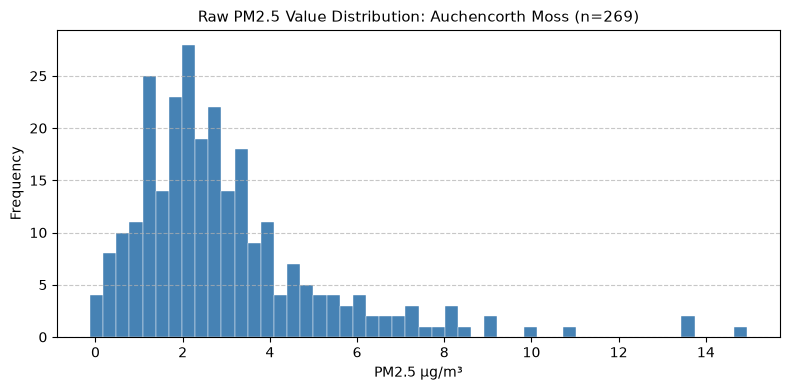

Saved: pm25_raw_distribution_Auchencorth_Moss.png


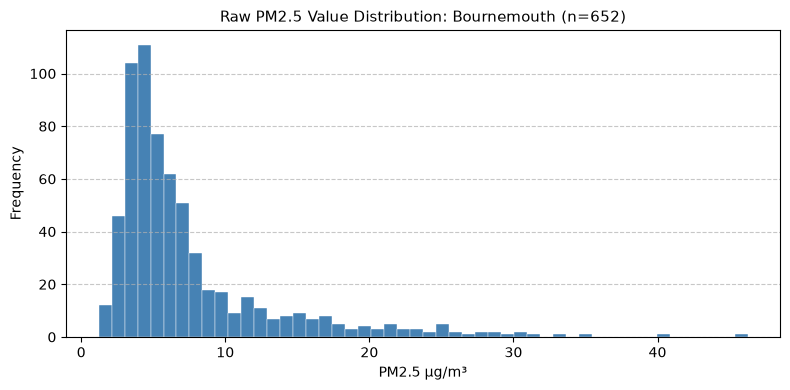

Saved: pm25_raw_distribution_Bournemouth.png


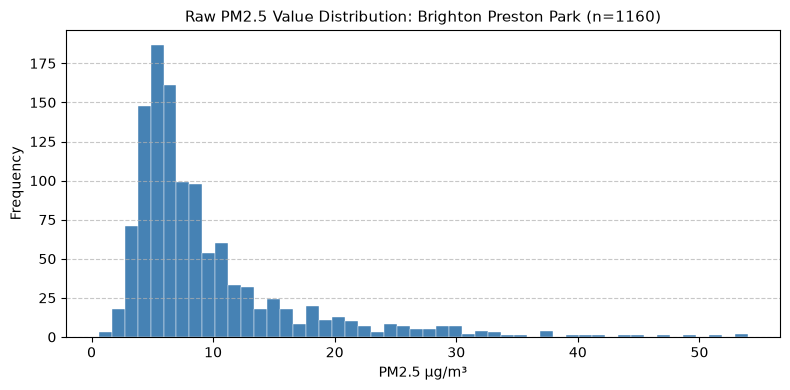

Saved: pm25_raw_distribution_Brighton_Preston_Park.png


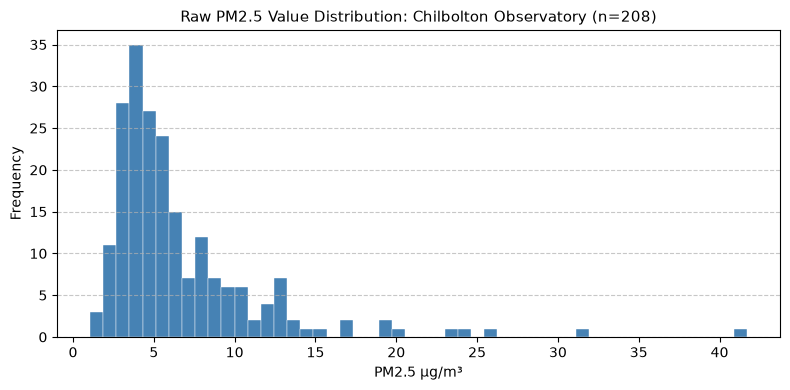

Saved: pm25_raw_distribution_Chilbolton_Observatory.png


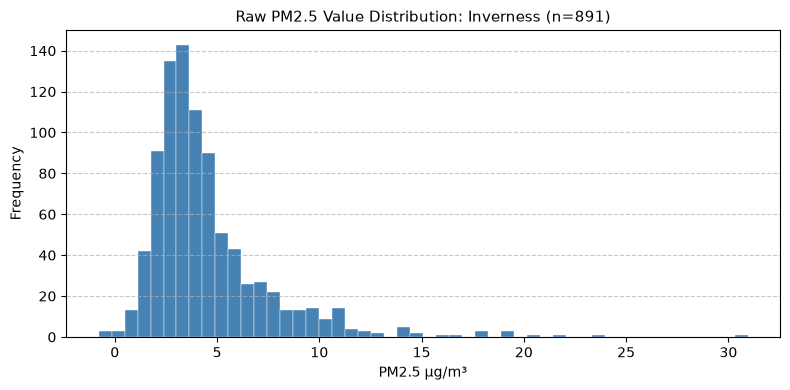

Saved: pm25_raw_distribution_Inverness.png


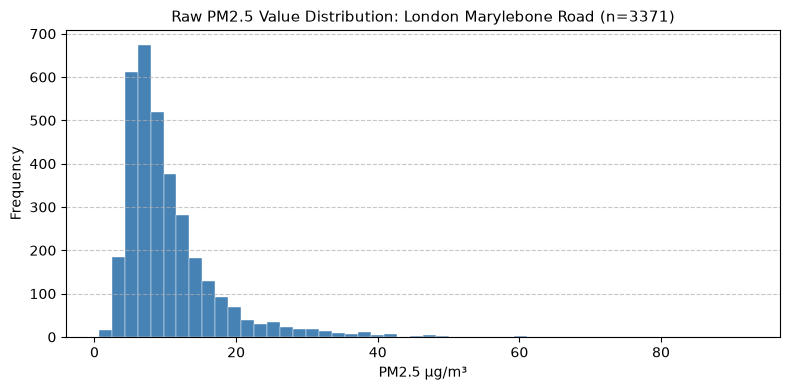

Saved: pm25_raw_distribution_London_Marylebone_Road.png


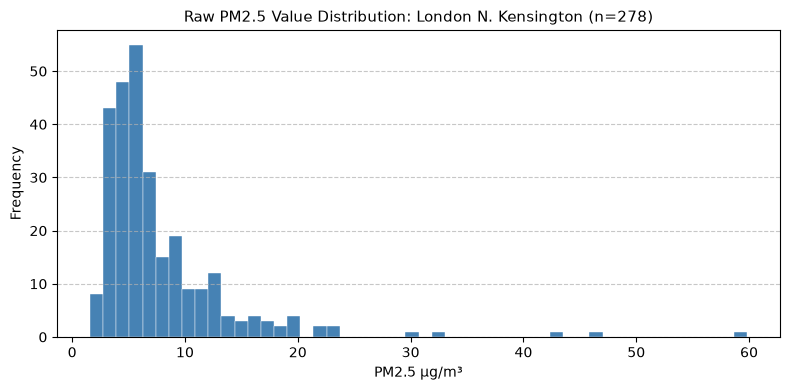

Saved: pm25_raw_distribution_London_N_Kensington.png


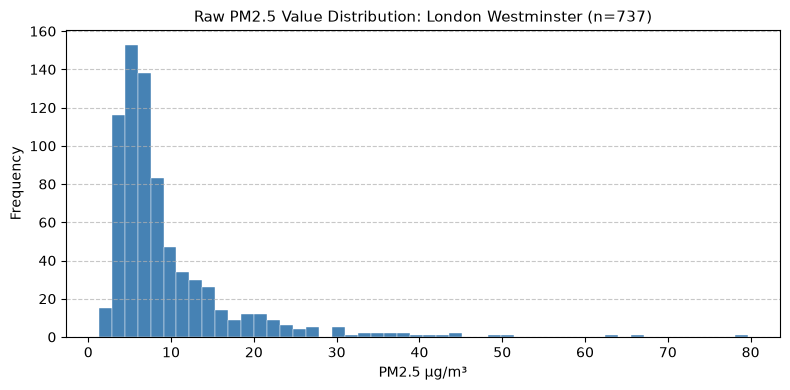

Saved: pm25_raw_distribution_London_Westminster.png


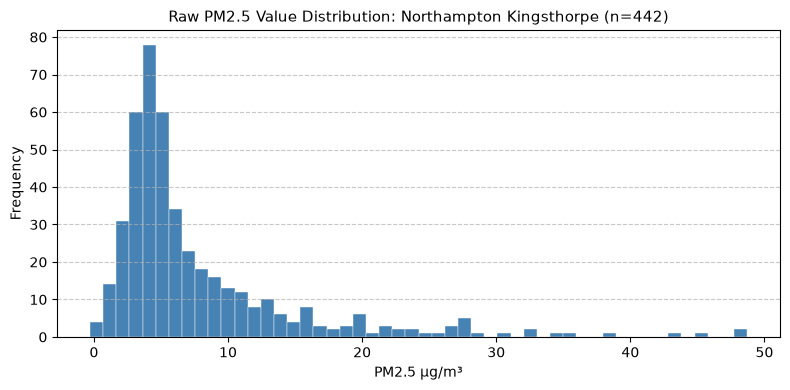

Saved: pm25_raw_distribution_Northampton_Kingsthorpe.png


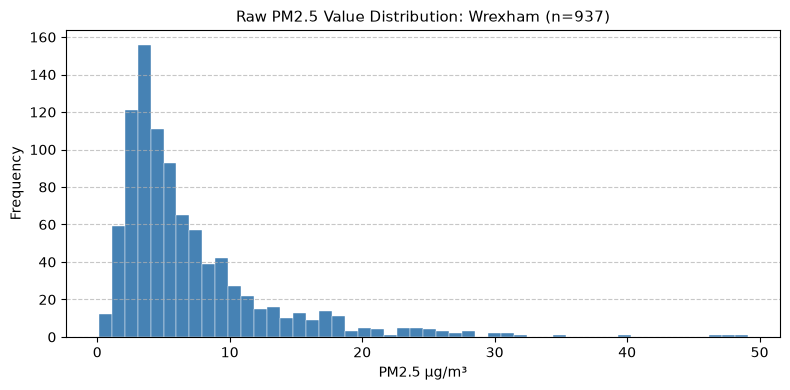

Saved: pm25_raw_distribution_Wrexham.png


In [180]:
# Distribution plots — raw values, no treatment
stations = df_dated['station'].unique()

for i, station in enumerate(stations):
    vals = df_dated[df_dated['station'] == station]['pm25_numeric'].dropna()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(f'Raw PM2.5 Value Distribution: {station} (n={len(vals)})', fontsize=11)
    ax.set_xlabel('PM2.5 µg/m³', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    filename = f"pm25_raw_distribution_{station.replace(' ', '_').replace('.', '')}.png"
    plt.savefig(os.path.join('plots', filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

## 6. Missing Values Profile
> Count and percentage of missing PM2.5 values per station. Includes both 'No data' string entries and truly absent rows.

In [181]:
print('--- Missing PM2.5 Values Per Station ---\n')
missing_summary = []

for station in df_dated['station'].unique():
    sdf = df_dated[df_dated['station'] == station]
    total = len(sdf)
    missing = sdf['pm25_numeric'].isna().sum()
    no_data_str = (sdf['pm25_raw'].astype(str).str.strip().str.lower() == 'no data').sum()

    missing_summary.append({
        'station': station,
        'total_rows': total,
        'missing_NaN': missing,
        'of_which_No_data_string': no_data_str,
        'missing_%': round(missing / total * 100, 2)
    })

missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))

--- Missing PM2.5 Values Per Station ---

                station  total_rows  missing_NaN  of_which_No_data_string  missing_%
       Auchencorth Moss         366           97                       96      26.50
            Bournemouth         731           79                       77      10.81
  Brighton Preston Park        1461          301                      297      20.60
 Chilbolton Observatory         366          158                       56      43.17
              Inverness        1096          205                       42      18.70
 London Marylebone Road        3657          286                      277       7.82
   London N. Kensington         366           88                        1      24.04
     London Westminster        1096          359                       50      32.76
Northampton Kingsthorpe         731          289                        9      39.53
                Wrexham        1096          159                       65      14.51


## 7. Duplicate Rows Profile
> Check for exact duplicate rows and duplicate (date, station) combinations.

In [182]:
exact_dupes = df_dated.duplicated().sum()
date_station_dupes = df_dated.duplicated(subset=['date', 'station']).sum()

print(f'Exact duplicate rows              : {exact_dupes}')
print(f'Duplicate (date, station) pairs   : {date_station_dupes}')

if date_station_dupes > 0:
    print('\nDuplicate (date, station) examples:')
    dupes = df_dated[df_dated.duplicated(subset=['date', 'station'], keep=False)]
    print(dupes[['date', 'station', 'pm25_raw']].head(20).to_string(index=False))

Exact duplicate rows              : 19
Duplicate (date, station) pairs   : 19

Duplicate (date, station) examples:
date                 station pm25_raw
 NaT             Bournemouth      NaN
 NaT   Brighton Preston Park      NaN
 NaT               Inverness      NaN
 NaT  London Marylebone Road      NaN
 NaT      London Westminster      NaN
 NaT Northampton Kingsthorpe      NaN
 NaT                 Wrexham      NaN
 NaT             Bournemouth      NaN
 NaT   Brighton Preston Park      NaN
 NaT               Inverness      NaN
 NaT  London Marylebone Road      NaN
 NaT      London Westminster      NaN
 NaT Northampton Kingsthorpe      NaN
 NaT                 Wrexham      NaN
 NaT   Brighton Preston Park      NaN
 NaT               Inverness      NaN
 NaT  London Marylebone Road      NaN
 NaT      London Westminster      NaN
 NaT                 Wrexham      NaN
 NaT   Brighton Preston Park      NaN


## 8. Status Field — Cardinality & Distribution
> The status column indicates data verification level. Profile its unique values and frequency.

In [183]:
# Extract the single-letter status code from the raw status string
# e.g. 'V ugm-3 (GRAV EMFAB)' -> 'V'
df_dated['status_code'] = df_dated['status_raw'].astype(str).str.strip().str[0]

print('--- Status Code Cardinality (All Stations Combined) ---')
status_counts = df_dated['status_code'].value_counts(dropna=False)
status_pct = (status_counts / len(df_dated) * 100).round(2)
status_summary = pd.DataFrame({'count': status_counts, '%': status_pct})
print(status_summary.to_string())
print()
print('Key: V=Verified  P=Provisionally Verified  N=Not Verified  S=Suspect  nan=missing')

print('\n--- Status Per Station ---')
print(df_dated.groupby('station')['status_code'].value_counts().to_string())

--- Status Code Cardinality (All Stations Combined) ---
             count      %
status_code              
V             9552  87.11
NaN           1414  12.89

Key: V=Verified  P=Provisionally Verified  N=Not Verified  S=Suspect  nan=missing

--- Status Per Station ---
station                  status_code
Auchencorth Moss         V               279
Bournemouth              V               668
Brighton Preston Park    V              1241
Chilbolton Observatory   V               264
Inverness                V               933
London Marylebone Road   V              3648
London N. Kensington     V               279
London Westminster       V               787
Northampton Kingsthorpe  V               451
Wrexham                  V              1002


## 9. Categorical Fields — Cardinality Summary
> Profile the categorical columns: station, status_code.

In [184]:
print('--- Categorical Field Cardinality ---\n')

cat_fields = {'station': df_dated['station'], 'status_code': df_dated['status_code']}

for field, series in cat_fields.items():
    print(f'Field: {field}')
    print(f'  Unique values : {series.nunique()}')
    print(f'  Value counts  :')
    vc = series.value_counts(dropna=False)
    for val, count in vc.items():
        print(f'    {str(val):<45} {count:>6} ({count/len(series)*100:.1f}%)')
    print()

--- Categorical Field Cardinality ---

Field: station
  Unique values : 10
  Value counts  :
    London Marylebone Road                          3657 (33.3%)
    Brighton Preston Park                           1461 (13.3%)
    Inverness                                       1096 (10.0%)
    London Westminster                              1096 (10.0%)
    Wrexham                                         1096 (10.0%)
    Bournemouth                                      731 (6.7%)
    Northampton Kingsthorpe                          731 (6.7%)
    Auchencorth Moss                                 366 (3.3%)
    Chilbolton Observatory                           366 (3.3%)
    London N. Kensington                             366 (3.3%)

Field: status_code
  Unique values : 1
  Value counts  :
    V                                               9552 (87.1%)
    nan                                             1414 (12.9%)



## 10. Overall Profile Summary
> Consolidated summary of all findings. No fixes have been applied.

In [185]:
total_rows = len(df_dated)
total_missing = df_dated['pm25_numeric'].isna().sum()
total_dupes = df_dated.duplicated(subset=['date', 'station']).sum()
total_negatives = (df_dated['pm25_numeric'] < 0).sum()
total_extreme = (df_dated['pm25_numeric'] > 150).sum()
total_gaps = gap_df['missing_dates_in_index'].sum()
total_stations = df_dated['station'].nunique()
status_verified = (df_dated['status_code'] == 'V').sum()
status_provisional = (df_dated['status_code'] == 'P').sum()
status_not_verified = (df_dated['status_code'] == 'N').sum()
status_suspect = (df_dated['status_code'] == 'S').sum()

print('=' * 55)
print('       PM2.5 RAW DATA PROFILE SUMMARY')
print('=' * 55)
print(f'  Files              : 2 (2016-2020, 2021-2025)')
print(f'  Total records      : {total_rows:,}')
print(f'  Stations           : {total_stations}')
print(f'  Date range         : {df_dated["date"].min().date()} to {df_dated["date"].max().date()}')
print()
print('  --- Missing Values ---')
print(f'  Missing PM2.5      : {total_missing:,} ({total_missing/total_rows*100:.2f}%)')
print()
print('  --- Duplicates ---')
print(f'  Duplicate rows     : {total_dupes}')
print()
print('  --- Time Index Gaps ---')
print(f'  Missing date slots : {total_gaps} (across all stations)')
print()
print('  --- Value Range Issues ---')
print(f'  Negative values    : {total_negatives}')
print(f'  Values > 150 µg/m³ : {total_extreme}')
print(f'  Min PM2.5 (raw)    : {df_dated["pm25_numeric"].min():.3f} µg/m³')
print(f'  Max PM2.5 (raw)    : {df_dated["pm25_numeric"].max():.3f} µg/m³')
print(f'  Overall mean       : {df_dated["pm25_numeric"].mean():.3f} µg/m³')
print()
print('  --- Status Codes ---')
print(f'  Verified (V)       : {status_verified:,}')
print(f'  Provisional (P)    : {status_provisional:,}')
print(f'  Not Verified (N)   : {status_not_verified:,}')
print(f'  Suspect (S)        : {status_suspect:,}')
print('=' * 55)
print('NOTE: No fixes have been applied in this notebook.')

       PM2.5 RAW DATA PROFILE SUMMARY
  Files              : 2 (2016-2020, 2021-2025)
  Total records      : 10,966
  Stations           : 10
  Date range         : 2016-01-01 to 2025-12-31

  --- Missing Values ---
  Missing PM2.5      : 2,021 (18.43%)

  --- Duplicates ---
  Duplicate rows     : 19

  --- Time Index Gaps ---
  Missing date slots : 16 (across all stations)

  --- Value Range Issues ---
  Negative values    : 7
  Values > 150 µg/m³ : 0
  Min PM2.5 (raw)    : -0.792 µg/m³
  Max PM2.5 (raw)    : 92.220 µg/m³
  Overall mean       : 8.560 µg/m³

  --- Status Codes ---
  Verified (V)       : 9,552
  Provisional (P)    : 0
  Not Verified (N)   : 0
  Suspect (S)        : 0
NOTE: No fixes have been applied in this notebook.


# #4 — Target Data: Missing value handling
**Assignee: hirunikeshika9600**

# #5 — Target Data: Outlier detection & treatment
**Assignee: Veenashaji1**

In [186]:
# Alias so Veena's outlier cells run without modification
# pm25_raw is still a raw string; use pm25_numeric which Veena's #2 already converted
df['pm25'] = df_dated['pm25_numeric']
# StringArray dtype causes groupby.apply to push station into the index — cast to plain str
df['station'] = df['station'].astype(str)

## Step 6: Outlier Detection (IQR + Domain Rules)

In [187]:
def detect_outliers(group):
    Q1 = group['pm25'].quantile(0.25)
    Q3 = group['pm25'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    # Domain rule: values above 150 µg/m³ are physically implausible for UK
    domain_upper = 150

    group = group.copy()
    group['iqr_outlier']    = (group['pm25'] < lower) | (group['pm25'] > upper)
    group['domain_outlier'] = group['pm25'] > domain_upper
    group['outlier']        = group['iqr_outlier'] | group['domain_outlier']
    group['iqr_lower']      = lower
    group['iqr_upper']      = upper
    return group

_station = df['station'].values
df = df.groupby('station', group_keys=False).apply(detect_outliers).reset_index(drop=True)
if 'station' not in df.columns:
    df['station'] = _station

print(f'Total outliers flagged : {df["outlier"].sum()} ({df["outlier"].sum()/len(df)*100:.2f}%)')
print(f'IQR outliers           : {df["iqr_outlier"].sum()}')
print(f'Domain outliers >150   : {df["domain_outlier"].sum()}')
print()
print('Outliers per station:')
print(df.groupby('station')['outlier'].sum().to_string())

Total outliers flagged : 253 (2.31%)
IQR outliers           : 253
Domain outliers >150   : 0

Outliers per station:
station
Auchencorth Moss            5
Bournemouth                32
Brighton Preston Park      43
Chilbolton Observatory      5
Inverness                  19
London Marylebone Road     74
London N. Kensington        7
London Westminster         24
Northampton Kingsthorpe    20
Wrexham                    24


## Step 7: Outlier Treatment
- **Domain outliers (>150 µg/m³)** → cap at 150 (physically implausible for UK)
- **IQR outliers** → flag only, keep original value (could be real events e.g. Saharan dust, Bonfire Night)
- **Suspect status (S)** → flag but keep

In [188]:
df['pm25_treated'] = df['pm25'].copy()
df.loc[df['domain_outlier'], 'pm25_treated'] = 150

print(f'Domain outliers capped at 150 µg/m³ : {df["domain_outlier"].sum()}')
print(f'IQR outliers flagged (values kept)   : {df["iqr_outlier"].sum()}')

Domain outliers capped at 150 µg/m³ : 0
IQR outliers flagged (values kept)   : 253


## Step 8: Rolling Statistics (7-day window spike detection)

In [189]:
df = df.sort_values(['station', 'date'])

df['rolling_mean_7d'] = df.groupby('station')['pm25_treated'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df['rolling_std_7d'] = df.groupby('station')['pm25_treated'].transform(
    lambda x: x.rolling(7, min_periods=1).std()
)

df['rolling_spike'] = abs(df['pm25_treated'] - df['rolling_mean_7d']) > (3 * df['rolling_std_7d'])

print(f'Rolling spike anomalies detected: {df["rolling_spike"].sum()}')

Rolling spike anomalies detected: 0


## Step 9: Quick Visualisation

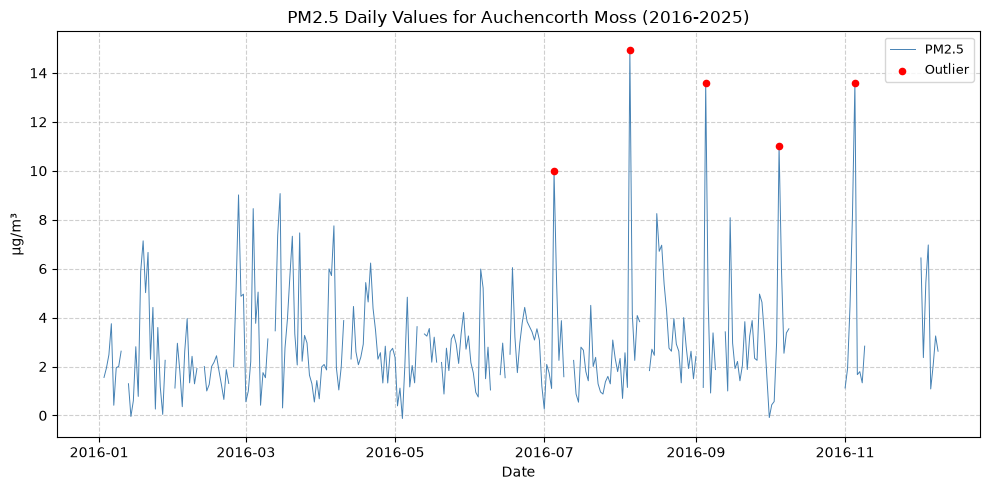

Plot saved as pm25_outlier_plot_Auchencorth_Moss.png


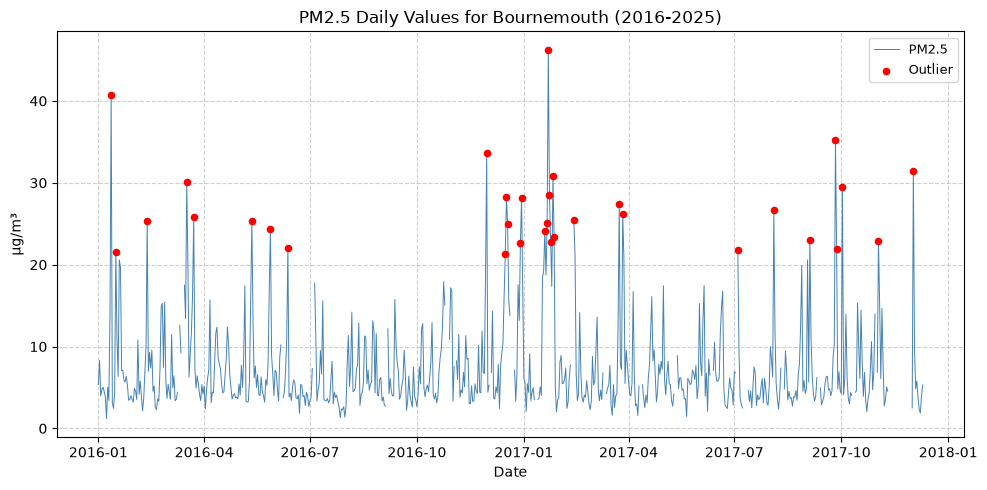

Plot saved as pm25_outlier_plot_Bournemouth.png


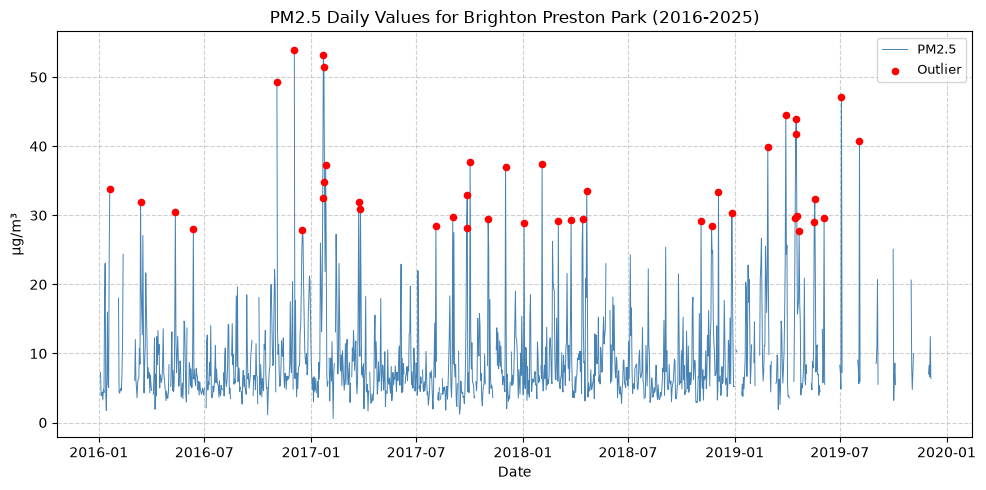

Plot saved as pm25_outlier_plot_Brighton_Preston_Park.png


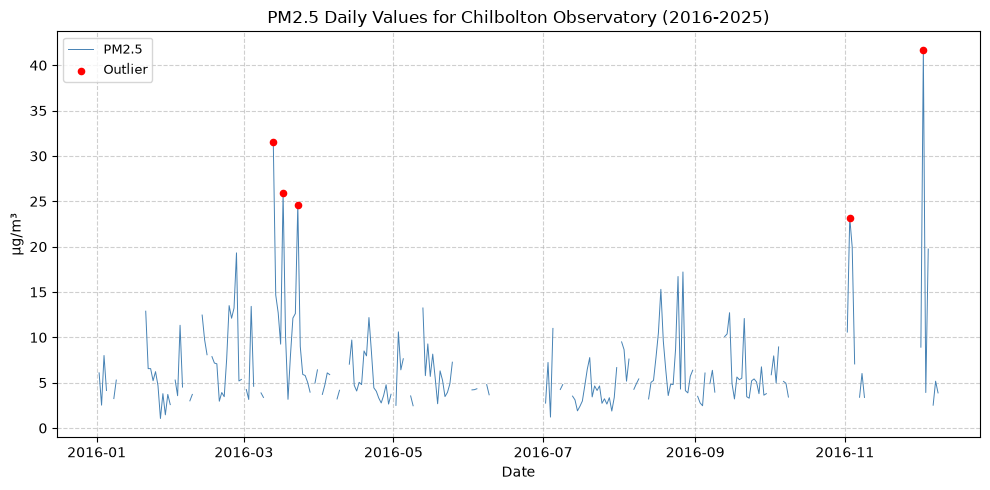

Plot saved as pm25_outlier_plot_Chilbolton_Observatory.png


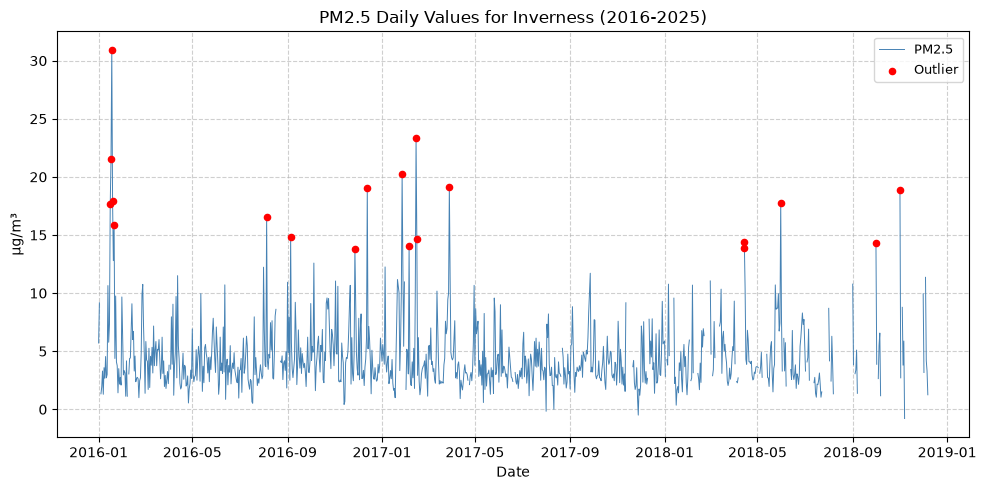

Plot saved as pm25_outlier_plot_Inverness.png


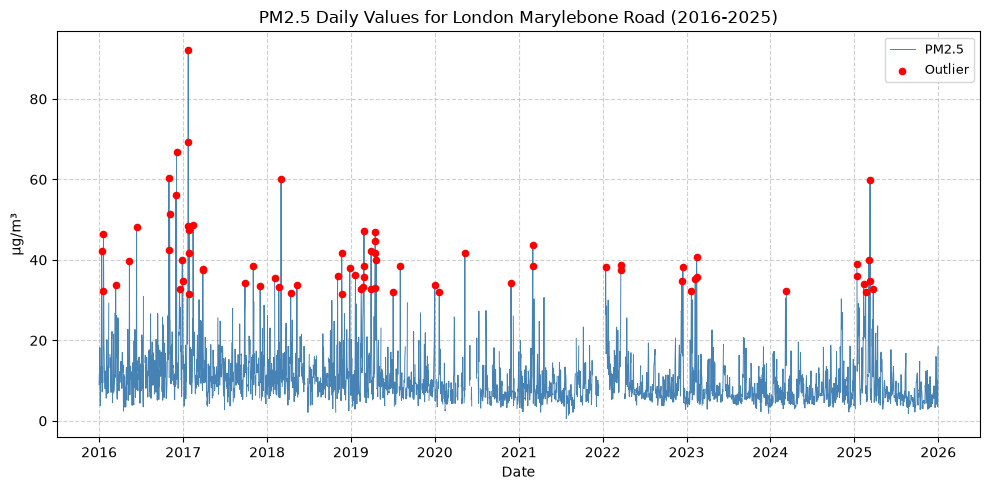

Plot saved as pm25_outlier_plot_London_Marylebone_Road.png


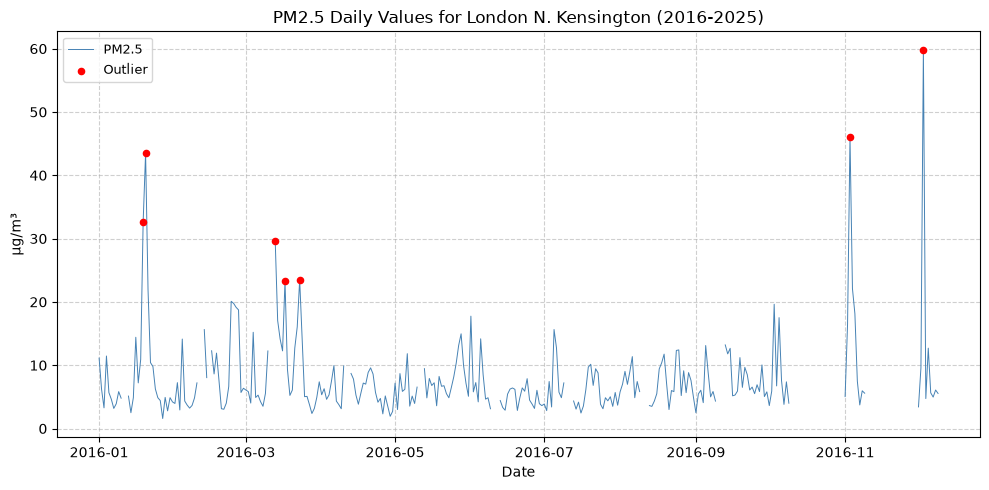

Plot saved as pm25_outlier_plot_London_N_Kensington.png


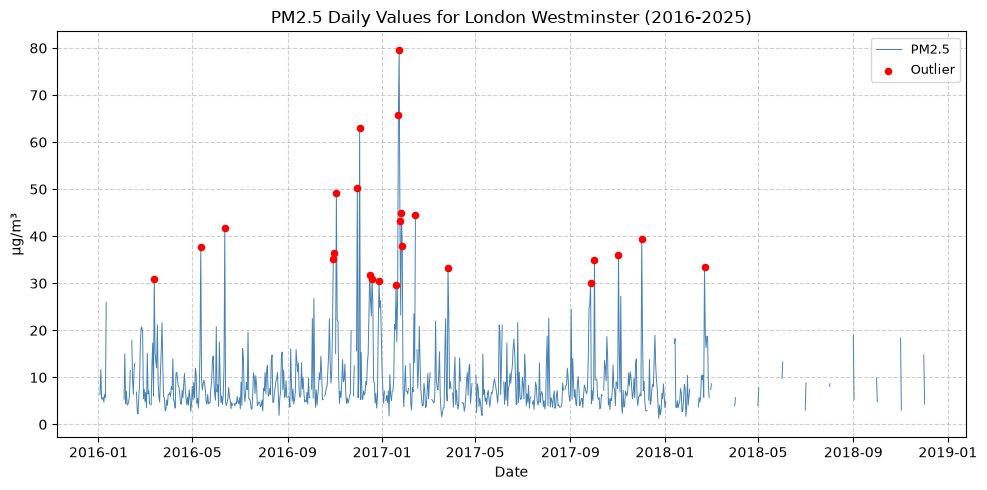

Plot saved as pm25_outlier_plot_London_Westminster.png


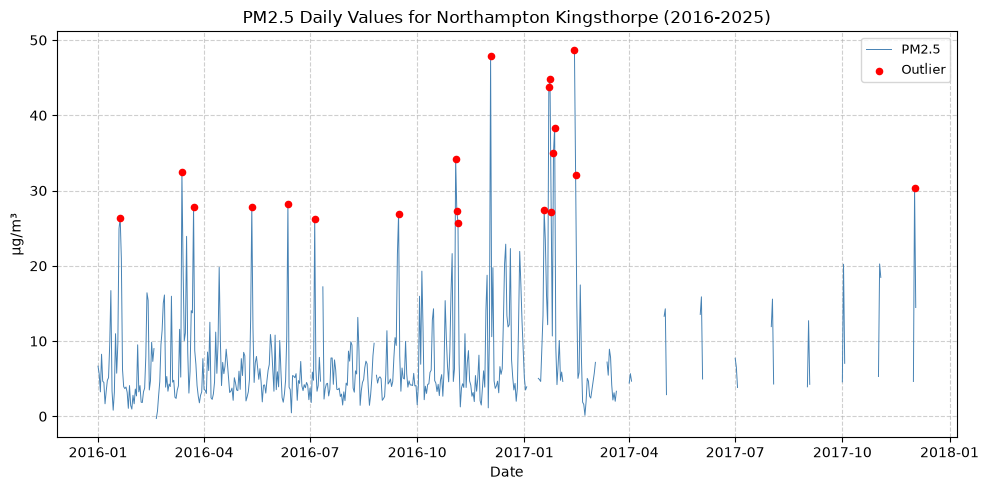

Plot saved as pm25_outlier_plot_Northampton_Kingsthorpe.png


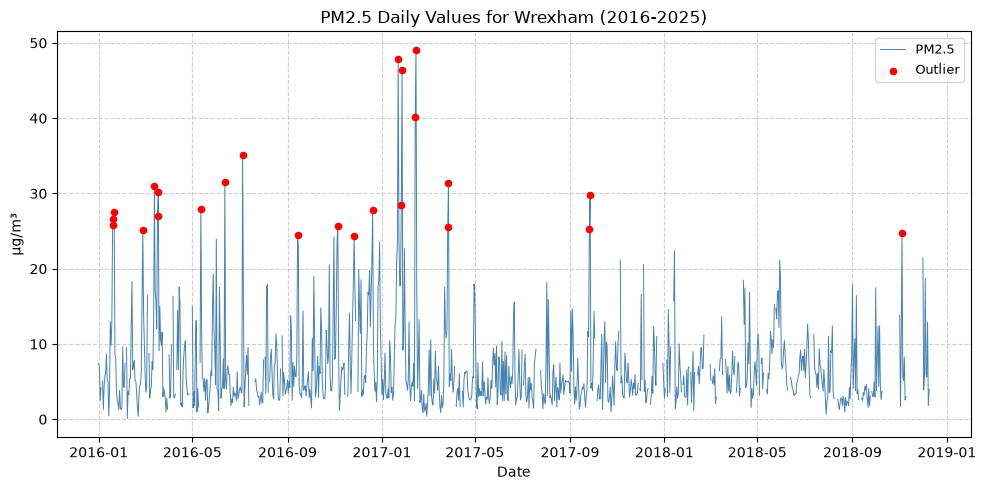

Plot saved as pm25_outlier_plot_Wrexham.png


In [190]:
stations = df['station'].unique()

for station in stations:
    sdf = df[df['station'] == station]

    fig, ax = plt.subplots(figsize=(10, 5)) # Create a new figure and axes for each station

    ax.plot(sdf['date'], sdf['pm25_treated'], linewidth=0.7, color='steelblue', label='PM2.5')
    outliers = sdf[sdf['outlier'] == True]
    ax.scatter(outliers['date'], outliers['pm25_treated'], color='red', s=20, zorder=5, label='Outlier')

    ax.set_title(f'PM2.5 Daily Values for {station} (2016-2025)', fontsize=12)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('µg/m³', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    filename = f'pm25_outlier_plot_{station.replace(" ", "_").replace(".", "")}.png'
    plt.savefig(os.path.join('plots', filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved as {filename}')


# #6 — Target Data: Scaling & encoding
**Assignee: hirunikeshika9600**

# #7 — Target Data: Train/val/test split
**Assignee: Matthew Butler (vexogon)**

Time series models require a continuous sequence of data for training and validation. By moving the longest continuous-day reading streaks to the train, validation, and test split section, we can ensure that our models are trained on reliable and uninterrupted data. Other options for handling gaps in the data include interpolation, forward/backward filling, or using models that can handle missing data. However, using continuous streaks of data is often the most straightforward and effective approach for time series modeling and given we have 989 days of continuous data, we can use that for training and validation without too much concern of underfitting.

In [191]:
# --- Per-day national-rule indicator ---
# How many distinct stations / regions report on each day, reindexed to the
# full daily range so missing days show up as False (rule not met).
df_plot = df.copy()
df_plot['date'] = df_plot['date'].dt.normalize()
full_range = pd.date_range(df_plot['date'].min(), df_plot['date'].max(), freq='D')

per_date = df_plot.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
rule_mask   = (per_date['n_stations'] >= 3) & (per_date['n_regions'] >= 2)
rule_series = rule_mask.reindex(full_range, fill_value=False)
print(f'Days where national rule is met: {int(rule_series.sum())} of {len(rule_series)} '
      f'({rule_series.mean()*100:.1f}%)')


Days where national rule is met: 1093 of 3653 (29.9%)


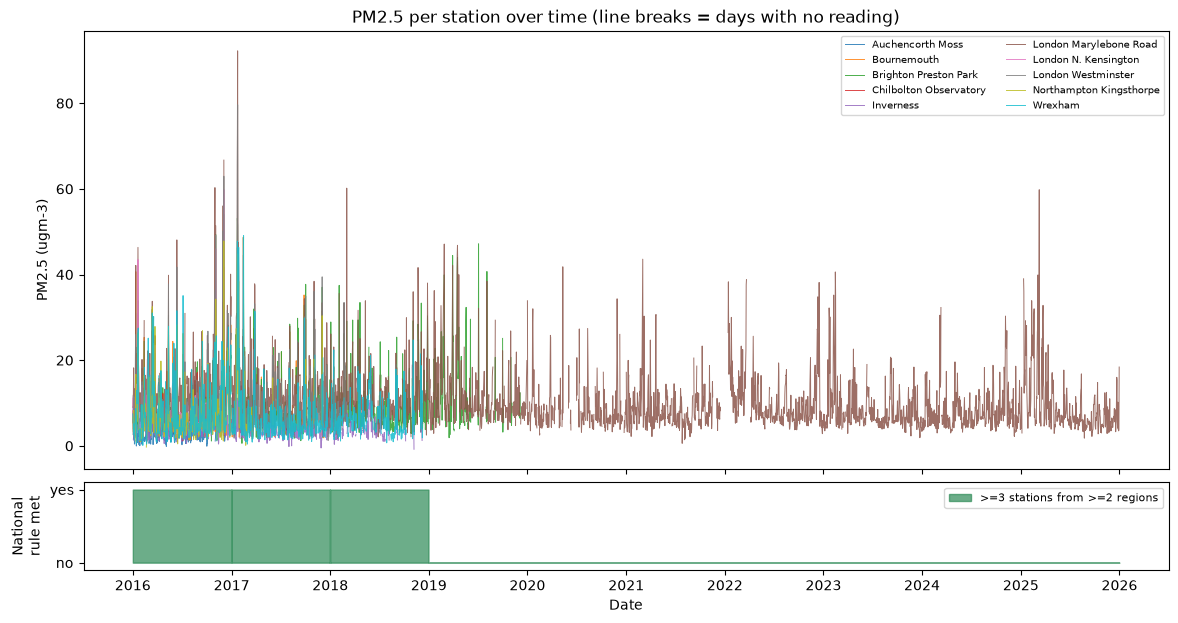

Saved: plots/national_rule_coverage_plot.png


In [192]:
# --- Coverage plot: per-station lines + national-rule indicator ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.05}
)

stations = sorted(df_plot['station'].astype(str).unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations)))
for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25'].mean()
             .reindex(full_range))
    ax_top.plot(sub.index, sub.values, linewidth=0.7, alpha=0.85, color=c, label=s)

ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title('PM2.5 per station over time (line breaks = days with no reading)')
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(full_range, 0, rule_series.astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1])
ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join('plots', 'national_rule_coverage_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/national_rule_coverage_plot.png")


In [193]:
# --- Find every contiguous run where the national rule fails ---
fail  = ~rule_series
group = (fail != fail.shift()).cumsum()
runs  = (pd.DataFrame({'date': rule_series.index,
                       'fail': fail.values, 'group': group.values})
           .query('fail')
           .groupby('group')
           .agg(start=('date', 'min'), end=('date', 'max'),
                length_days=('date', 'size'))
           .reset_index(drop=True))
print(f'Total rule-failure runs: {len(runs)}')
print(runs.head(10).to_string(index=False))


Total rule-failure runs: 3
     start        end  length_days
2016-12-31 2016-12-31            1
2017-12-31 2017-12-31            1
2018-12-31 2025-12-31         2558


In [194]:
# --- Gaps overlapping 2018 (sorted by length) ---
mask_2018 = (runs['start'].dt.year <= 2018) & (runs['end'].dt.year >= 2018)
gaps_2018 = runs[mask_2018].sort_values('length_days', ascending=False).copy()

print('Rule-failure gaps overlapping 2018:')
if gaps_2018.empty:
    print('  (none)')
else:
    print(gaps_2018.assign(start=gaps_2018['start'].dt.date,
                           end=gaps_2018['end'].dt.date)
                   .to_string(index=False))
    print(f'\nTotal rule-failing days inside 2018: '
          f'{int(fail.loc["2018"].sum())} of {len(fail.loc["2018"])}')


Rule-failure gaps overlapping 2018:
     start        end  length_days
2018-12-31 2025-12-31         2558

Total rule-failing days inside 2018: 1 of 365


In [195]:
# --- Pick the biggest 2018-touching gap and its zoom window ---
gap = gaps_2018.iloc[0]   # already sorted by length descending

pad = pd.Timedelta(days=180)
win_start = max(gap['start'] - pad, full_range.min())
win_end   = min(gap['end']   + pad, full_range.max())
zoom_idx  = full_range[(full_range >= win_start) & (full_range <= win_end)]
print(f"Gap: {gap['start'].date()} -> {gap['end'].date()} "
      f"({gap['length_days']} days)")
print(f"Zoom window: {win_start.date()} -> {win_end.date()} ({len(zoom_idx)} days)")


Gap: 2018-12-31 -> 2025-12-31 (2558 days)
Zoom window: 2018-07-04 -> 2025-12-31 (2738 days)


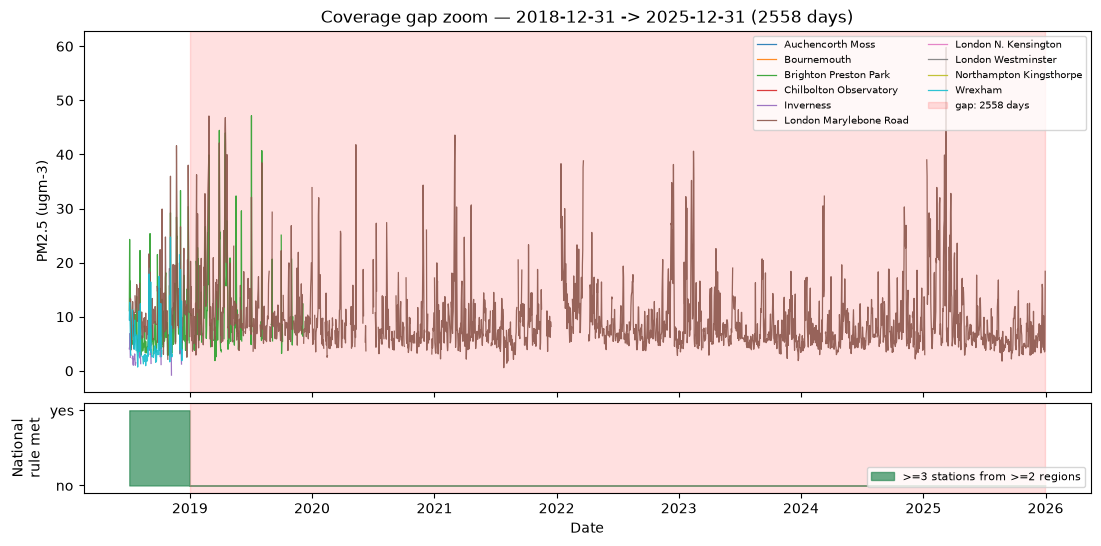

Saved: plots/national_rule_gap_zoom_plot.png


In [196]:
# --- Zoomed coverage plot around the chosen gap ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
)

for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25'].mean()
             .reindex(zoom_idx))
    ax_top.plot(sub.index, sub.values, linewidth=0.9, alpha=0.9, color=c, label=s)

ax_top.axvspan(gap['start'], gap['end'], color='red', alpha=0.12,
               label=f"gap: {gap['length_days']} days")
ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title(f"Coverage gap zoom — {gap['start'].date()} -> {gap['end'].date()} "
                 f"({gap['length_days']} days)")
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(zoom_idx, 0, rule_series.loc[zoom_idx].astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.axvspan(gap['start'], gap['end'], color='red', alpha=0.12)
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1]); ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join('plots', 'national_rule_gap_zoom_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/national_rule_gap_zoom_plot.png")


#### Longest consecutive-day reading streaks

In [197]:
# --- Helper: longest consecutive-day run in a date series ---
def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']


In [198]:
# --- Longest streak per station ---
rows = []
for station, sub in df.groupby('station'):
    n, start, end = longest_run(sub['date'])
    rows.append({'station': station, 'longest_run_days': n,
                 'start': start.date(), 'end': end.date()})
per_station_runs = (pd.DataFrame(rows)
                      .sort_values('longest_run_days', ascending=False)
                      .reset_index(drop=True))
print('Longest consecutive-day streak per station:')
print(per_station_runs.to_string(index=False))


Longest consecutive-day streak per station:
                station  longest_run_days      start        end
 London Marylebone Road              1826 2021-01-01 2025-12-31
       Auchencorth Moss               365 2016-01-01 2016-12-30
            Bournemouth               365 2016-01-01 2016-12-30
  Brighton Preston Park               365 2016-01-01 2016-12-30
 Chilbolton Observatory               365 2016-01-01 2016-12-30
              Inverness               365 2016-01-01 2016-12-30
   London N. Kensington               365 2016-01-01 2016-12-30
     London Westminster               365 2016-01-01 2016-12-30
Northampton Kingsthorpe               365 2016-01-01 2016-12-30
                Wrexham               365 2016-01-01 2016-12-30


## The "national" coverage rule

A single monitoring station, or a handful of stations clustered in one city, cannot stand in for the whole country. To make sure each daily value reflects *national* conditions rather than a local signal, a day only qualifies when it meets **two conditions at once**:

- **≥ 3 stations reporting** — averaging over at least three monitors prevents any single station's noise, calibration drift, or outage from dominating that day's value.
- **≥ 2 regions represented** — the reporting stations must span at least two distinct regions, so the average cannot be driven entirely by (say) three London sites. This enforces geographic spread.

Days that fail *either* condition are treated as gaps and masked to `NaN` rather than averaged.

The check below reports the **longest unbroken run** of qualifying days: that contiguous stretch is what gives us a usable, gap-free window for training the time-series model.

In [199]:
# --- Longest streak for the national rule ---
per_date_full = df.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
national_dates = per_date_full[(per_date_full['n_stations'] >= 3) &
                               (per_date_full['n_regions']  >= 2)].index.to_series()
n, start, end = longest_run(national_dates)
print(f'National rule (>=3 stations, >=2 regions):')
print(f'  longest gap-free run: {n} days  ({start.date()} -> {end.date()})')
print(f'  total qualifying days: {len(national_dates)}')


National rule (>=3 stations, >=2 regions):
  longest gap-free run: 365 days  (2016-01-01 -> 2016-12-30)
  total qualifying days: 1093


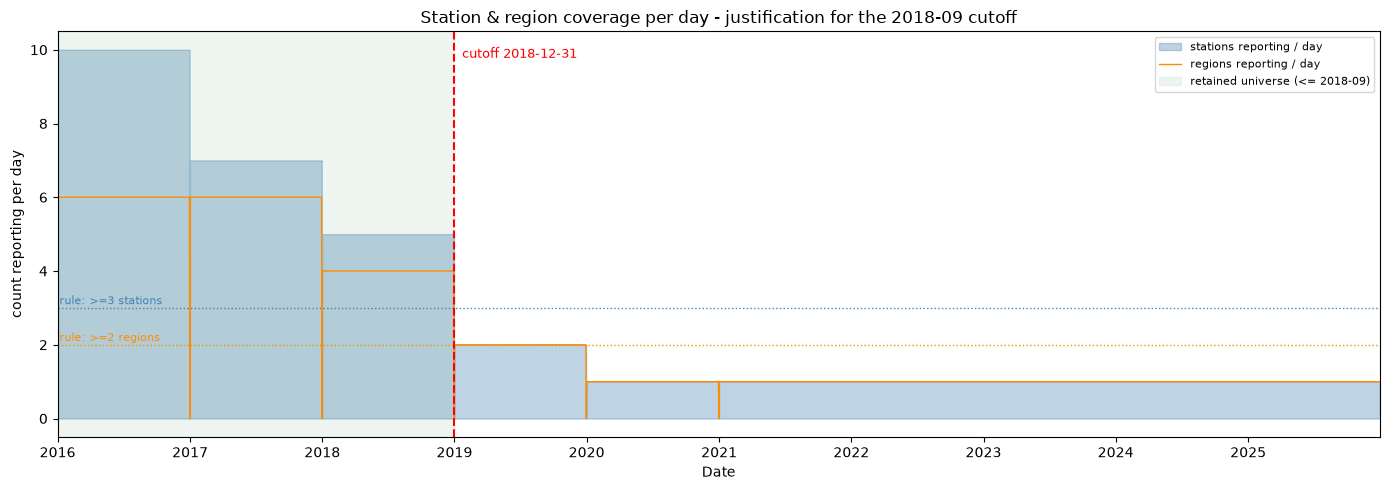

Before cutoff: mean 7.3 stations/day, national rule met on 100% of days
After  cutoff: mean 1.1 stations/day, national rule met on 0% of days
Saved: plots/universe_cutoff_justification.png


In [200]:
# --- Justification for the 2018-09 cutoff: coverage collapses afterwards ---
cutoff = pd.Timestamp('2018-12-31')

# Daily coverage across the full range (reindex so absent days show as 0)
cov = per_date.reindex(full_range).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(cov.index, 0, cov['n_stations'], step='mid',
                color='steelblue', alpha=0.35, label='stations reporting / day')
ax.plot(cov.index, cov['n_regions'], color='darkorange', linewidth=1.0,
        label='regions reporting / day')

# National-rule thresholds
ax.axhline(3, color='steelblue', linestyle=':', linewidth=1)
ax.axhline(2, color='darkorange', linestyle=':', linewidth=1)
ax.text(cov.index[5], 3.1, 'rule: >=3 stations', color='steelblue', fontsize=8)
ax.text(cov.index[5], 2.1, 'rule: >=2 regions', color='darkorange', fontsize=8)

# Retained universe shading + cutoff line
ax.axvspan(cov.index.min(), cutoff, color='seagreen', alpha=0.08,
           label='retained universe (<= 2018-09)')
ax.axvline(cutoff, color='red', linestyle='--', linewidth=1.5)
ymax = ax.get_ylim()[1]
ax.text(cutoff, ymax * 0.96, f'  cutoff {cutoff.date()}', color='red', fontsize=9, va='top')

ax.set_title('Station & region coverage per day - justification for the 2018-09 cutoff')
ax.set_xlabel('Date'); ax.set_ylabel('count reporting per day')
ax.legend(loc='upper right', fontsize=8)
ax.margins(x=0)
plt.tight_layout()
plt.savefig(os.path.join('plots', 'universe_cutoff_justification.png'), dpi=150, bbox_inches='tight')
plt.show()

# Quantify the collapse either side of the cutoff
post_idx = full_range[full_range > cutoff]
pre_met  = rule_series.loc[:cutoff].mean() * 100
post_met = rule_series.loc[post_idx].mean() * 100 if len(post_idx) else float('nan')
print(f'Before cutoff: mean {cov.loc[:cutoff, "n_stations"].mean():.1f} stations/day, '
      f'national rule met on {pre_met:.0f}% of days')
print(f'After  cutoff: mean {cov.loc[post_idx, "n_stations"].mean():.1f} stations/day, '
      f'national rule met on {post_met:.0f}% of days')
print('Saved: plots/universe_cutoff_justification.png')

## What do about the gaps?

It appears that post 12 2018, large gaps in the data appear and continue to voliate our national rule from this point forward. We can either drop these stations entirely, or we can use interpolation to fill in the gaps. 

We will drop all data after 12 2018, as this is the point where the data becomes unreliable and violates our national rule and there is no reasonable way to interpolate the data without introducing bias or inaccuracies. By dropping this data, we can ensure that our analysis and modeling are based on reliable and consistent data.

#### Filling gaps pre 12 2018:

The gaps in the data pre 12 2018 are relatively small and can be filled using interpolation.

We will use multiple methods for this:

Short gaps - Linear interpolation: For gaps of 1-2 days, we can use linear interpolation to fill in the missing values. This method assumes that the change between the two known values is linear and can be used to estimate the missing value. This will create 'straight lines' between the known values, which is a reasonable assumption for short gaps.

Medium gaps - Cross-station regression: For gaps of 3+ days, we can use cross-station regression to fill in the missing values. This method uses the readings from co-reporting stations to estimate the missing value based on the relationship between the stations. This will create a more accurate estimate of the missing value, as it takes into account the readings from other stations.

In order to use cross-station regression, we will need to first split our data into training and testing sets. We will use the training set to build the regression model and the testing set to evaluate its performance. This will prevent data leakage.

## Chronological split:

Chronological split is a method of splitting the data into training, validation, and test sets based on time. This is important for time series modeling, as it ensures that the model is trained on past data and tested on future data.

The 'universe` here just means the time period we are considering for our analysis.

In [201]:
# --- Universe and split window definitions ---
# Restrict the modelling universe to the pre-cliff period and split it
# chronologically (never shuffled).
UNIVERSE_START = '2016-01-01'
UNIVERSE_END   = '2018-12-31'

SPLITS = [
    ('train', '2016-01-01', '2017-12-31'),   # 24 mo, two full seasonal cycles
    ('val',   '2018-01-01', '2018-04-30'),   # 4 mo, hyperparameter tuning
    ('test',  '2018-05-01', '2018-12-31'),   # 8 mo, held-out forecast window
]


In [202]:
# --- Filter to the universe and assign a split label to every row ---
in_universe = (df['date'] >= pd.Timestamp(UNIVERSE_START)) & \
              (df['date'] <= pd.Timestamp(UNIVERSE_END))
df = df[in_universe].copy()

def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return 'unassigned'

df['split'] = df['date'].apply(assign_split).astype('category')
print(f'Universe: {UNIVERSE_START} -> {UNIVERSE_END}')
print(f'Total rows after restriction: {len(df)}')


Universe: 2016-01-01 -> 2018-12-31
Total rows after restriction: 8018


In [203]:
# --- Aggregate per date: mean PM2.5 + coverage diagnostics ---
national = (df.groupby('date', as_index=False)
              .agg(pm25=('pm25', 'mean'),
                   n_stations=('station', 'nunique'),
                   n_regions=('region', 'nunique'),
                   split=('split', 'first')))
print(f'National shape (before reindex): {national.shape}')


National shape (before reindex): (1093, 5)


In [204]:
# --- Strict daily index across the universe so any gaps stay visible ---
full_idx = pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D', name='date')
national = national.set_index('date').reindex(full_idx).reset_index()
national['split'] = (national['split']
                     .fillna(national['date'].apply(assign_split))
                     .astype('category'))
print(f'National shape (after reindex): {national.shape}')
print(f'Rows added by reindex (no station reported): {national["pm25"].isna().sum()}')


National shape (after reindex): (1096, 5)
Rows added by reindex (no station reported): 3


In [205]:
# --- Mask rule-failing days to NaN + per-split summary ---
rule_fails = ((national['n_stations'].fillna(0) < 3) |
              (national['n_regions'].fillna(0)  < 2))
national.loc[rule_fails, 'pm25'] = np.nan

print(f'Days masked as NaN (no rule-quality reading): {int(rule_fails.sum())}')
print('\nPer-split summary of national series:')
print(national.groupby('split', observed=True)
              .agg(rows=('pm25', 'size'),
                   missing=('pm25', lambda s: int(s.isna().sum())),
                   mean_pm25=('pm25', 'mean'),
                   median_pm25=('pm25', 'median'),
                   min_stations=('n_stations', 'min'),
                   max_stations=('n_stations', 'max'))
              .round(2)
              .to_string())
print('\nHead:')
print(national.head().to_string(index=False))


Days masked as NaN (no rule-quality reading): 3

Per-split summary of national series:
       rows  missing  mean_pm25  median_pm25  min_stations  max_stations
split                                                                   
test    245        1       8.82         7.45           5.0           5.0
train   731        2       8.20         6.26           7.0          10.0
val     120        0       9.20         7.16           5.0           5.0

Head:
      date     pm25  n_stations  n_regions split
2016-01-01 7.313444        10.0        6.0 train
2016-01-02 7.656714        10.0        6.0 train
2016-01-03 4.422750        10.0        6.0 train
2016-01-04 7.701000        10.0        6.0 train
2016-01-05 4.670667        10.0        6.0 train


In [206]:
def find_rule_gaps(df, split_name):
    sub = df[df['split'] == split_name]
    per_day = sub.groupby('date').agg(n_stations=('station', 'nunique'),
                                      n_regions=('region', 'nunique'))
    rule_ok = (per_day['n_stations'] >= 3) & (per_day['n_regions'] >= 2)
    all_dates = pd.date_range(per_day.index.min(), per_day.index.max())
    # missing = physically absent OR present but fails the rule
    physically_missing = all_dates.difference(per_day.index)
    rule_failing       = per_day.index[~rule_ok]
    return physically_missing.union(rule_failing).sort_values()

for split_name in ['train', 'val', 'test']:
    gaps = find_rule_gaps(df, split_name)
    print(f"{split_name}: {len(gaps)} day(s) failing national rule")
    if len(gaps):
        print(f"  {list(gaps.strftime('%Y-%m-%d'))}")

train: 1 day(s) failing national rule
  ['2016-12-31']
val: 0 day(s) failing national rule
test: 0 day(s) failing national rule


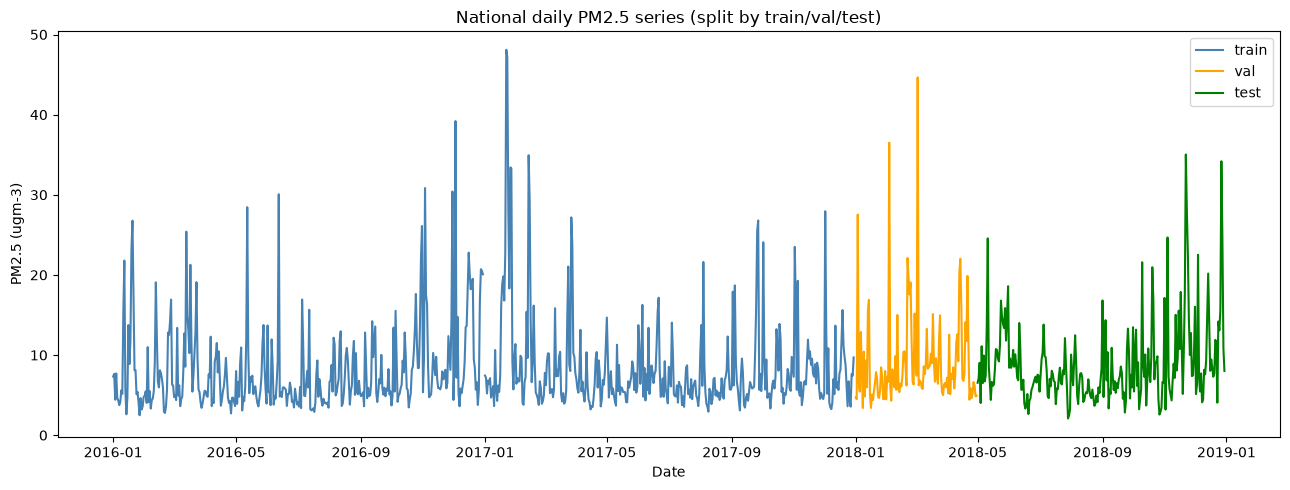

Saved: plots/national_daily_pm25_splits.png


In [207]:
#plot time series of each split

fig, ax = plt.subplots(figsize=(13, 5))
for split_name, color in zip(['train', 'val', 'test'], ['steelblue', 'orange', 'green']):
    sub = national[national['split'] == split_name]
    ax.plot(sub['date'], sub['pm25'], label=split_name, color=color)
ax.set_title('National daily PM2.5 series (split by train/val/test)')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join('plots', 'national_daily_pm25_splits.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/national_daily_pm25_splits.png")


# #8 — Target Data: Pipeline packaging
**Assignee: Matthew Butler (vexogon)**

In [208]:
# --- Export the train/val/test splits ---
# The national daily series (one PM2.5 value per day) is the modelling target.
# Each split is written to its own CSV, plus one combined file with the labels.
import os

SPLIT_DIR = 'data/splits'
os.makedirs(SPLIT_DIR, exist_ok=True)

split_cols = ['date', 'pm25', 'split', 'n_stations', 'n_regions']
print('--- National daily series splits ---')
for split_name in ['train', 'val', 'test']:
    part = national.loc[national['split'] == split_name, split_cols].copy()
    path = os.path.join(SPLIT_DIR, f'national_{split_name}.csv')
    part.to_csv(path, index=False)
    span = f'{part["date"].min().date()} -> {part["date"].max().date()}' if len(part) else 'empty'
    print(f'  {split_name:5}: {len(part):4} rows ({span})  missing pm25={int(part["pm25"].isna().sum())}  ->  {path}')

# Combined national series (all rows, with split label)
all_path = os.path.join(SPLIT_DIR, 'national_all.csv')
national[split_cols].to_csv(all_path, index=False)
print(f'\n  combined: {len(national)} rows  ->  {all_path}')

# Per-station cleaned rows carry the same split label too — export if useful
per_station_path = os.path.join(SPLIT_DIR, 'per_station_with_split.csv')
ps_cols = ['date', 'station', 'region', 'pm25', 'pm25_treated', 'outlier', 'split']
df[ps_cols].to_csv(per_station_path, index=False)
print(f'  per-station: {len(df)} rows  ->  {per_station_path}')

--- National daily series splits ---
  train:  731 rows (2016-01-01 -> 2017-12-31)  missing pm25=2  ->  data/splits/national_train.csv
  val  :  120 rows (2018-01-01 -> 2018-04-30)  missing pm25=0  ->  data/splits/national_val.csv
  test :  245 rows (2018-05-01 -> 2018-12-31)  missing pm25=1  ->  data/splits/national_test.csv

  combined: 1096 rows  ->  data/splits/national_all.csv
  per-station: 8018 rows  ->  data/splits/per_station_with_split.csv


# #9 — Locate and store target data
**Assignee: Veenashaji1**

## Step 10: Save Cleaned File

In [209]:
output_cols = ['date', 'station', 'pm25', 'pm25_treated', 'status_raw',
               'outlier', 'iqr_flagged', 'domain_outlier', 'rolling_spike',
               'rolling_mean_7d', 'rolling_std_7d']

# iqr_flagged = same as iqr_outlier, just rename for clarity
df['iqr_flagged'] = df['iqr_outlier']

df[output_cols].to_csv('pm25_cleaned.csv', index=False)
print('Saved: pm25_cleaned.csv')

print(f"""
--- FINAL SUMMARY ---
Total records   : {len(df)}
Stations        : {df['station'].nunique()}
Date range      : {df['date'].min().date()} to {df['date'].max().date()}
Missing PM2.5   : {df['pm25'].isna().sum()}
Outliers flagged: {df['outlier'].sum()}
Domain capped   : {df['domain_outlier'].sum()}
Rolling spikes  : {df['rolling_spike'].sum()}
""")

Saved: pm25_cleaned.csv

--- FINAL SUMMARY ---
Total records   : 8018
Stations        : 10
Date range      : 2016-01-01 to 2018-12-30
Missing PM2.5   : 1557
Outliers flagged: 202
Domain capped   : 0
Rolling spikes  : 0



# #10 — Create advisory document
**Assignee: hirunikeshika9600**